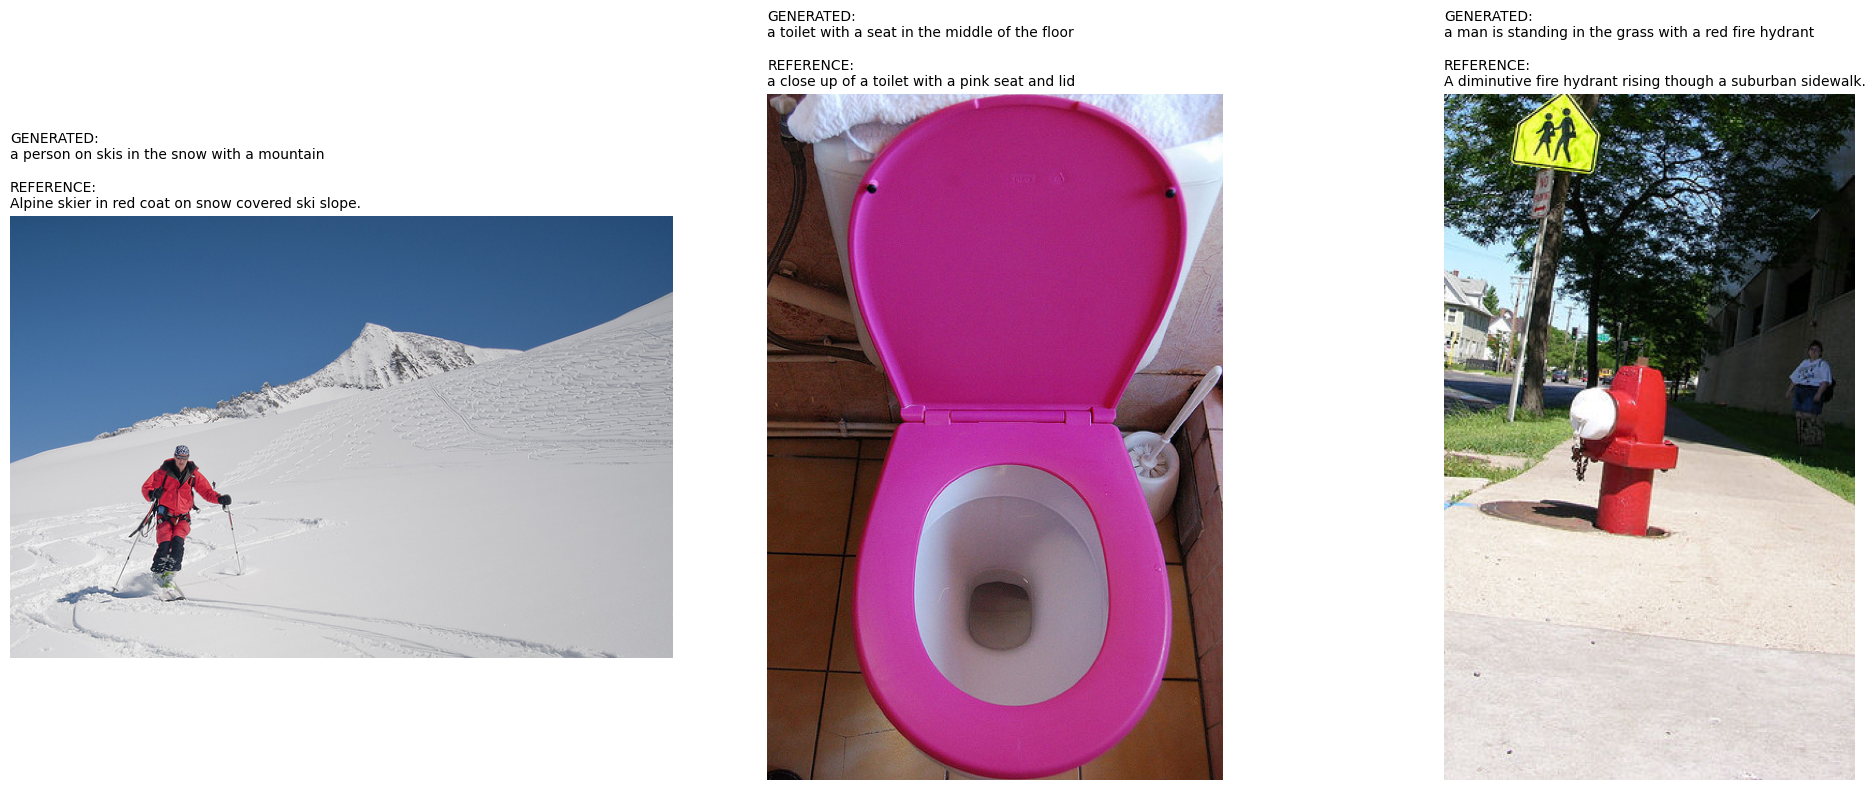

In [3]:
import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from PIL import Image
import random


MODEL_PATH = "/home/jovyan/lab3/additive-upgraded-20260511-125646.pt"
VAL_FEATURES_PATH = "/home/jovyan/annabell/val_features.pt"
VAL_PREPROCESSED_PATH = "/home/jovyan/lab3/coco_val_preprocessed_new.pt"


class ImageCaptionModel(nn.Module):
    def __init__(self, vocab_size, max_length):
        super(ImageCaptionModel, self).__init__()
        self.image_embedding = nn.Sequential(
            nn.Linear(25088, 512),
            nn.ReLU(),
            nn.Dropout(0.3) 
        )
        self.caption_embedding = nn.Embedding(vocab_size, 512)
        self.lstm = nn.LSTM(input_size=512, hidden_size=512, batch_first=True)
        self.lstm_dropout = nn.Dropout(0.5)
        self.output_layer = nn.Linear(512, vocab_size)

    def forward(self, image_features, captions):
        img_emb = self.image_embedding(image_features)
        cap_emb = self.caption_embedding(captions)
        lstm_out, _ = self.lstm(cap_emb)
        lstm_out = self.lstm_dropout(lstm_out)
        img_expanded = img_emb.unsqueeze(1).repeat(1, lstm_out.size(1), 1)
        combined = lstm_out + img_expanded
        return self.output_layer(combined)


def generate_caption(model, image_feature, vocab, idx_to_word, max_length=30, device="cpu"):
    model.eval()
    with torch.no_grad():
        img = image_feature.unsqueeze(0).to(device)
        img_emb = model.image_embedding(img)
        
        # Start token
        input_token = torch.tensor([[vocab["<start>"]]], device=device)
        hidden = None  # Initialize hidden state as None
        words = []

        for _ in range(max_length):
            cap_emb = model.caption_embedding(input_token)
            

            lstm_out, hidden = model.lstm(cap_emb, hidden)
            
            combined = lstm_out + img_emb.unsqueeze(1)
            logits = model.output_layer(combined)
            
            next_token = logits.argmax(dim=-1)
            word = idx_to_word.get(next_token.item(), "<unk>")

            if word == "<end>":
                break
            if word not in ("<start>", "<pad>"):
                words.append(word)

            input_token = next_token # Prepare for next iteration

    return " ".join(words)


def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    checkpoint = torch.load(MODEL_PATH, map_location=device)
    vocab = checkpoint["vocab"]
    idx_to_word = {int(k): v for k, v in checkpoint["idx_to_word"].items()}
    max_length = checkpoint["max_length"]

    model = ImageCaptionModel(len(vocab), max_length).to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    
    val_features = torch.load(VAL_FEATURES_PATH)
    val_data = torch.load(VAL_PREPROCESSED_PATH)
    val_samples = val_data["samples"]
    
    feature_lookup = {os.path.basename(k): v for k, v in val_features.items()}
    valid_samples = [s for s in val_samples if os.path.basename(s["image_path"]) in feature_lookup]
    
    # Select 3 random samples
    random_samples = random.sample(valid_samples, k=3)

    plt.figure(figsize=(20, 8))

    for i, sample in enumerate(random_samples):
        img_path = sample["image_path"]
        img_filename = os.path.basename(img_path)
        
        feat = feature_lookup[img_filename].float()
        generated = generate_caption(model, feat, vocab, idx_to_word, max_length, device)
        
        original = sample["caption"]
        if isinstance(original, dict):
            original = original.get("caption", "")

        try:
            img = Image.open(img_path).convert("RGB")
            plt.subplot(1, 3, i + 1)
            plt.imshow(img)
            plt.title(f"GENERATED:\n{generated}\n\nREFERENCE:\n{original}", fontsize=10, loc='left')
            plt.axis("off")
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

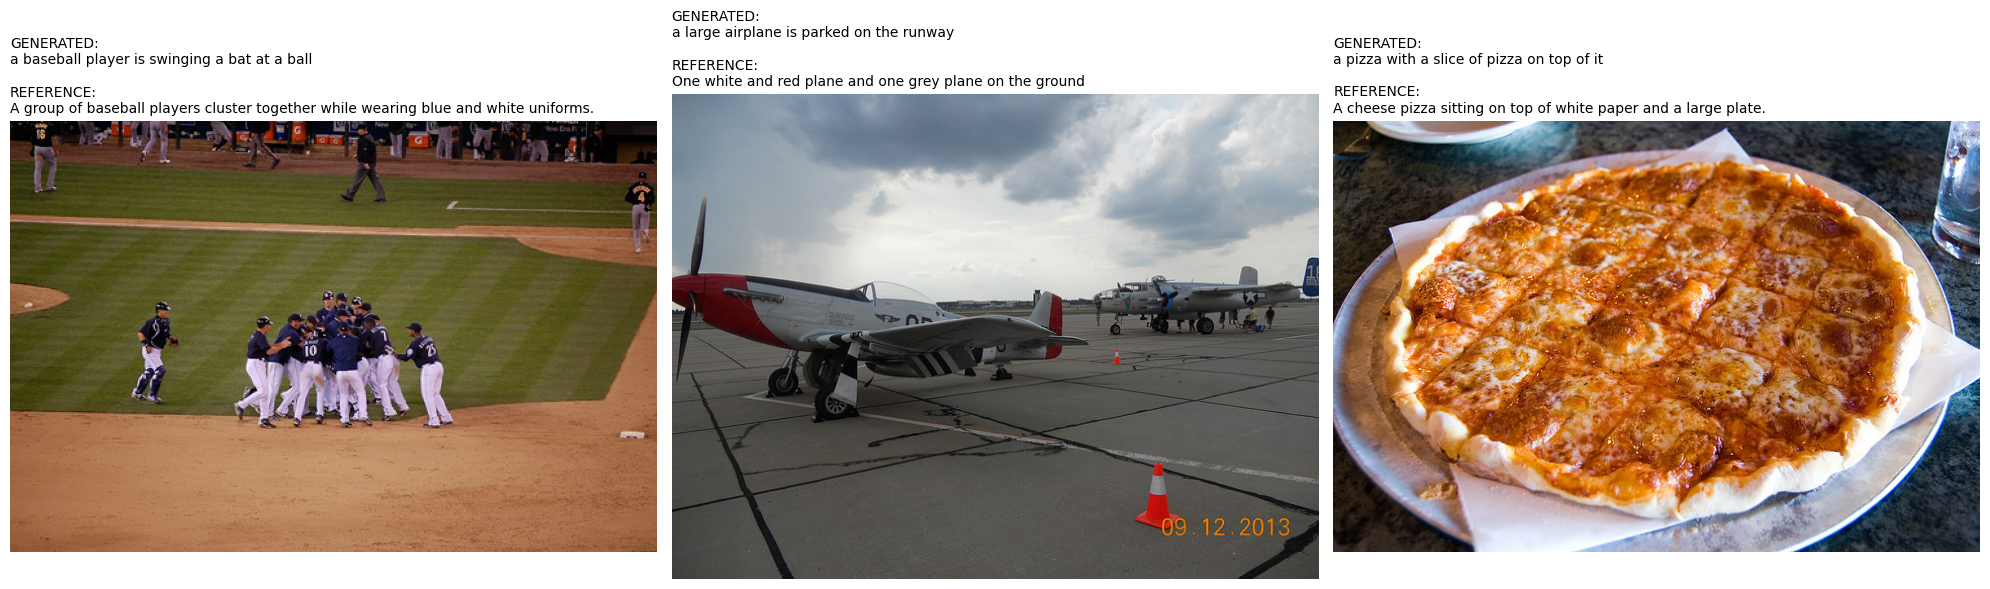

In [3]:
#Attention inference
import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from PIL import Image
import random


MODEL_PATH = "/home/jovyan/lab3/attention-hidden-inject-20260511-141425.pt"
VAL_FEATURES_PATH = "/home/jovyan/annabell/val_features.pt"
VAL_PREPROCESSED_PATH = "/home/jovyan/lab3/coco_val_preprocessed_new.pt"

class ImageCaptionModel(nn.Module):
    def __init__(self, vocab_size, max_length):
        super(ImageCaptionModel, self).__init__()

        self.image_embedding = nn.Sequential(
            nn.Linear(25088, 512),
            nn.ReLU(),
            nn.Dropout(0.3) 
        )

        self.caption_embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=512
        )
        
        self.lstm = nn.LSTM(
            input_size=512,
            hidden_size=512,
            batch_first=True
        )
        self.lstm_dropout = nn.Dropout(0.5)

        self.attention = nn.MultiheadAttention(embed_dim=512, num_heads=8, batch_first=True)
        self.output_layer = nn.Linear(512, vocab_size)

    def forward(self, image_features, captions):
        img_emb = self.image_embedding(image_features)             # (batch, 512)
        cap_emb = self.caption_embedding(captions)                 # (batch, seq_len, 512)

        h0 = img_emb.unsqueeze(0)                                  # (1, batch, 512)
        c0 = torch.zeros_like(h0) 
        
        lstm_out, _ = self.lstm(cap_emb, (h0, c0))                 # (batch, seq_len, 512)
        lstm_out = self.lstm_dropout(lstm_out)

        img_context = img_emb.unsqueeze(1)                         # (batch, 1, 512)
        attn_output, _ = self.attention(query=lstm_out, key=img_context, value=img_context)
        
        combined = lstm_out + attn_output 
        return self.output_layer(combined)


def generate_caption(model, image_feature, vocab, idx_to_word, max_length=30, device="cpu"):
    model.eval()
    with torch.no_grad():
        img = image_feature.unsqueeze(0).to(device)
        img_emb = model.image_embedding(img)
        img_context = img_emb.unsqueeze(1)

        h = img_emb.unsqueeze(0) 
        c = torch.zeros_like(h)
        hidden = (h, c)

        input_token = torch.tensor([[vocab["<start>"]]], device=device)
        words = []

        for _ in range(max_length):
            cap_emb = model.caption_embedding(input_token)
            lstm_out, hidden = model.lstm(cap_emb, hidden)
            
            attn_out, _ = model.attention(query=lstm_out, key=img_context, value=img_context)
            logits = model.output_layer(lstm_out + attn_out)

            next_token = logits.argmax(dim=-1)
            word = idx_to_word.get(next_token.item(), "<unk>")

            if word == "<end>": break
            if word not in ("<start>", "<pad>"): words.append(word)
            input_token = next_token

    return " ".join(words)


def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    checkpoint = torch.load(MODEL_PATH, map_location=device)
    vocab = checkpoint["vocab"]
    idx_to_word = {int(k): v for k, v in checkpoint["idx_to_word"].items()}
    max_length = checkpoint["max_length"]

    model = ImageCaptionModel(len(vocab), max_length).to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    
    val_features = torch.load(VAL_FEATURES_PATH)
    val_data = torch.load(VAL_PREPROCESSED_PATH)
    val_samples = val_data["samples"]
    
    feature_lookup = {os.path.basename(k): v for k, v in val_features.items()}
    valid_samples = [s for s in val_samples if os.path.basename(s["image_path"]) in feature_lookup]
    
    # Select 3 random samples
    random_samples = random.sample(valid_samples, k=3)

    plt.figure(figsize=(20, 8))

    for i, sample in enumerate(random_samples):
        img_path = sample["image_path"]
        img_filename = os.path.basename(img_path)
        
        feat = feature_lookup[img_filename].float()
        generated = generate_caption(model, feat, vocab, idx_to_word, max_length, device)
        
        original = sample["caption"]
        if isinstance(original, dict):
            original = original.get("caption", "")

        try:
            img = Image.open(img_path).convert("RGB")
            plt.subplot(1, 3, i + 1)
            plt.imshow(img)
            plt.title(f"GENERATED:\n{generated}\n\nREFERENCE:\n{original}", fontsize=10, loc='left')
            plt.axis("off")
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

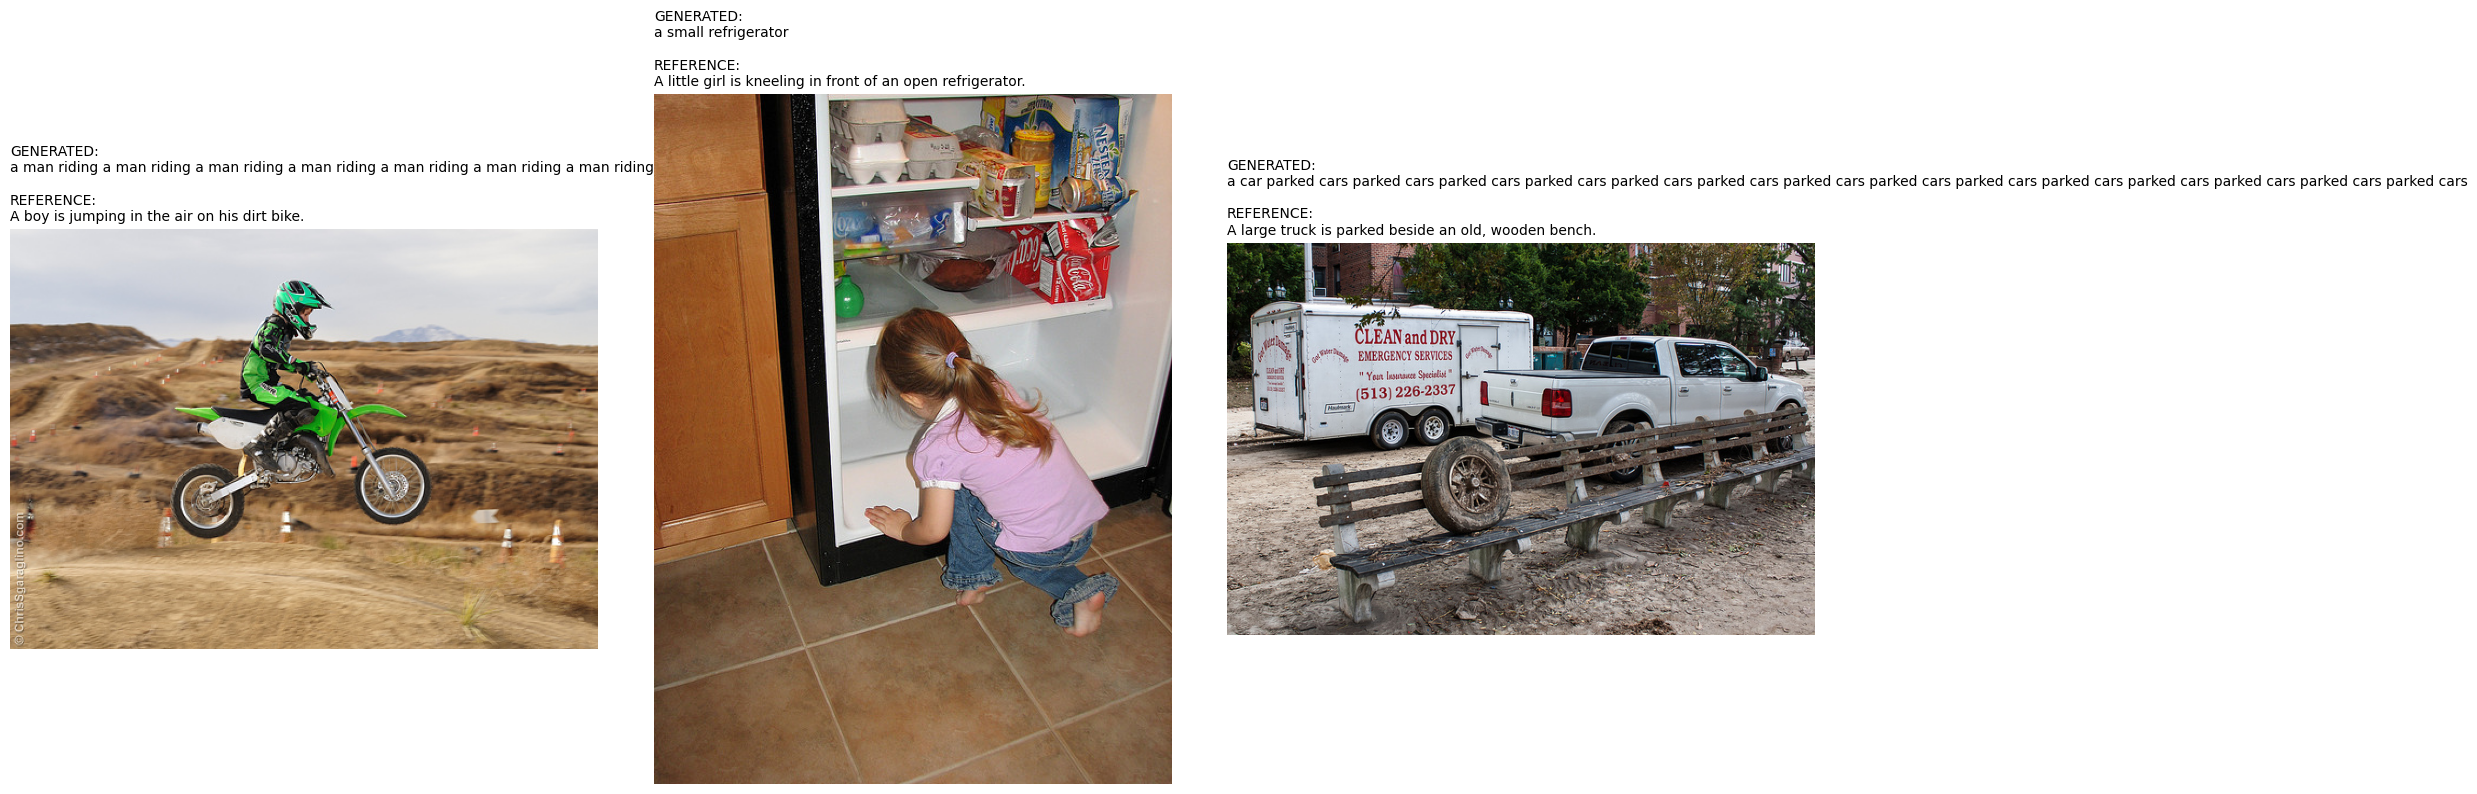

In [4]:
import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from PIL import Image
import random


MODEL_PATH = "/home/jovyan/lab3/additive-upgraded-20260511-125646.pt"
VAL_FEATURES_PATH = "/home/jovyan/annabell/val_features.pt"
VAL_PREPROCESSED_PATH = "/home/jovyan/lab3/coco_val_preprocessed_new.pt"


class ImageCaptionModel(nn.Module):
    def __init__(self, vocab_size, max_length):
        super(ImageCaptionModel, self).__init__()
        self.image_embedding = nn.Sequential(
            nn.Linear(25088, 512),
            nn.ReLU(),
            nn.Dropout(0.3) 
        )
        self.caption_embedding = nn.Embedding(vocab_size, 512)
        self.lstm = nn.LSTM(input_size=512, hidden_size=512, batch_first=True)
        self.lstm_dropout = nn.Dropout(0.5)
        self.output_layer = nn.Linear(512, vocab_size)

    def forward(self, image_features, captions):
        img_emb = self.image_embedding(image_features)
        cap_emb = self.caption_embedding(captions)
        lstm_out, _ = self.lstm(cap_emb)
        lstm_out = self.lstm_dropout(lstm_out)
        img_expanded = img_emb.unsqueeze(1).repeat(1, lstm_out.size(1), 1)
        combined = lstm_out + img_expanded
        return self.output_layer(combined)


def generate_caption(model, image_feature, vocab, idx_to_word, max_length=30, device="cpu"):
    model.eval()
    with torch.no_grad():
        img = image_feature.unsqueeze(0).to(device)
        img_emb = model.image_embedding(img)
        
        # Start token
        input_token = torch.tensor([[vocab["<start>"]]], device=device)
        hidden = None  # Initialize hidden state as None
        words = []

        for _ in range(max_length):
            cap_emb = model.caption_embedding(input_token)
            

            lstm_out, _ = model.lstm(cap_emb, hidden)
            
            combined = lstm_out + img_emb.unsqueeze(1)
            logits = model.output_layer(combined)
            
            next_token = logits.argmax(dim=-1)
            word = idx_to_word.get(next_token.item(), "<unk>")

            if word == "<end>":
                break
            if word not in ("<start>", "<pad>"):
                words.append(word)

            input_token = next_token # Prepare for next iteration

    return " ".join(words)


def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    checkpoint = torch.load(MODEL_PATH, map_location=device)
    vocab = checkpoint["vocab"]
    idx_to_word = {int(k): v for k, v in checkpoint["idx_to_word"].items()}
    max_length = checkpoint["max_length"]

    model = ImageCaptionModel(len(vocab), max_length).to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    
    val_features = torch.load(VAL_FEATURES_PATH)
    val_data = torch.load(VAL_PREPROCESSED_PATH)
    val_samples = val_data["samples"]
    
    feature_lookup = {os.path.basename(k): v for k, v in val_features.items()}
    valid_samples = [s for s in val_samples if os.path.basename(s["image_path"]) in feature_lookup]
    
    # Select 3 random samples
    random_samples = random.sample(valid_samples, k=3)

    plt.figure(figsize=(20, 8))

    for i, sample in enumerate(random_samples):
        img_path = sample["image_path"]
        img_filename = os.path.basename(img_path)
        
        feat = feature_lookup[img_filename].float()
        generated = generate_caption(model, feat, vocab, idx_to_word, max_length, device)
        
        original = sample["caption"]
        if isinstance(original, dict):
            original = original.get("caption", "")

        try:
            img = Image.open(img_path).convert("RGB")
            plt.subplot(1, 3, i + 1)
            plt.imshow(img)
            plt.title(f"GENERATED:\n{generated}\n\nREFERENCE:\n{original}", fontsize=10, loc='left')
            plt.axis("off")
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()
    

In [ ]:
#Image upload
# Imports

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
import torchvision.models as models
import zipfile
from PIL import Image
import io
from tqdm import tqdm

# Preprocessing images

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


# Load pretrained VGG16
backbone = models.vgg16(pretrained=True)

# Keep only the convolutional feature layers
feature_extractor = backbone.features

feature_extractor.eval()
# Feature extraction

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")  # good to confirm what you're actually on

# Move model to device
feature_extractor = feature_extractor.to(device)


# ------Save the features from train_images------

zip_path_train = "/home/jovyan/megan/labb3/data/coco/train_images.zip"

feature_dict_train = {}

with zipfile.ZipFile(zip_path_train, 'r') as zf:
    image_files_train = [f for f in zf.namelist() if f.endswith('.jpg')]

    for fname in tqdm(image_files_train, desc="Extracting train features"):
        with zf.open(fname) as f:
            img = Image.open(io.BytesIO(f.read())).convert("RGB")
            img_tensor = transform(img).unsqueeze(0).to(device)
            
            with torch.no_grad():
                features = feature_extractor(img_tensor) # (1, 512, 7, 7)
            
            feature_dict_train[fname] = features.view(features.size(0), -1).squeeze().cpu() # (25088,)
            

torch.save(feature_dict_train, "/home/jovyan/annabell/train_features.pt")


# ------Save the features from val_images------

zip_path_val = "/home/jovyan/megan/labb3/data/coco/val_images.zip"

feature_dict_val = {}

with zipfile.ZipFile(zip_path_val, 'r') as zf:
    image_files_val = [f for f in zf.namelist() if f.endswith('.jpg')]
    
    for fname in tqdm(image_files_val, desc="Extracting val features"):
        with zf.open(fname) as f:
            img = Image.open(io.BytesIO(f.read())).convert("RGB")
            img_tensor = transform(img).unsqueeze(0).to(device)
            
            with torch.no_grad():
                features = feature_extractor(img_tensor) # (1, 512, 7, 7)
            
            feature_dict_val[fname] = features.view(features.size(0), -1).squeeze().cpu() # (25088,)
            

torch.save(feature_dict_val, "/home/jovyan/annabell/val_features.pt")

Using device: cuda
Generated caption: a polar bear standing on a rock near a body of water


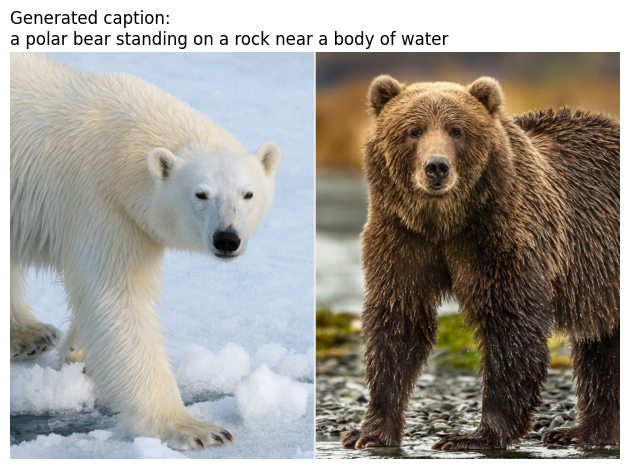

In [9]:
# Imports
import torch
import torch.nn as nn
from torchvision import transforms
import torchvision.models as models
from PIL import Image
import matplotlib.pyplot as plt

# ------ CONFIG ------
IMAGE_PATH = "/home/jovyan/lab3/prizzly-bears-polar-and-grizzly-5a6aee4d710b4c07a4ab8c9c69ef980d-4219847134.jpg"
MODEL_PATH = "/home/jovyan/lab3/additive-upgraded-20260511-125646.pt"

# ------ PREPROCESSING ------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ------ MODEL DEFINITION ------
class ImageCaptionModel(nn.Module):
    def __init__(self, vocab_size, max_length):
        super(ImageCaptionModel, self).__init__()
        self.image_embedding = nn.Sequential(
            nn.Linear(25088, 512),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        self.caption_embedding = nn.Embedding(vocab_size, 512)
        self.lstm = nn.LSTM(input_size=512, hidden_size=512, batch_first=True)
        self.lstm_dropout = nn.Dropout(0.5)
        self.output_layer = nn.Linear(512, vocab_size)

    def forward(self, image_features, captions):
        img_emb = self.image_embedding(image_features)
        cap_emb = self.caption_embedding(captions)
        lstm_out, _ = self.lstm(cap_emb)
        lstm_out = self.lstm_dropout(lstm_out)
        img_expanded = img_emb.unsqueeze(1).repeat(1, lstm_out.size(1), 1)
        combined = lstm_out + img_expanded
        return self.output_layer(combined)

# ------ CAPTION GENERATION ------
def generate_caption(model, image_feature, vocab, idx_to_word, max_length=30, device="cpu"):
    model.eval()
    with torch.no_grad():
        img = image_feature.unsqueeze(0).to(device)
        img_emb = model.image_embedding(img)

        input_token = torch.tensor([[vocab["<start>"]]], device=device)
        hidden = None
        words = []

        for _ in range(max_length):
            cap_emb = model.caption_embedding(input_token)
            lstm_out, hidden = model.lstm(cap_emb, hidden)
            combined = lstm_out + img_emb.unsqueeze(1)
            logits = model.output_layer(combined)

            next_token = logits.argmax(dim=-1)
            word = idx_to_word.get(next_token.item(), "<unk>")

            if word == "<end>":
                break
            if word not in ("<start>", "<pad>"):
                words.append(word)

            input_token = next_token

    return " ".join(words)

# ------ MAIN ------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load model checkpoint
checkpoint = torch.load(MODEL_PATH, map_location=device)
vocab = checkpoint["vocab"]
idx_to_word = {int(k): v for k, v in checkpoint["idx_to_word"].items()}
max_length = checkpoint["max_length"]

model = ImageCaptionModel(len(vocab), max_length).to(device)
model.load_state_dict(checkpoint["model_state_dict"])

# Extract features from input image
backbone = models.vgg16(pretrained=True)
feature_extractor = backbone.features.eval().to(device)

img = Image.open(IMAGE_PATH).convert("RGB")
img_tensor = transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    features = feature_extractor(img_tensor)          # (1, 512, 7, 7)

feature_vector = features.view(features.size(0), -1).squeeze().cpu().float()  # (25088,)

# Generate and display caption
caption = generate_caption(model, feature_vector, vocab, idx_to_word, max_length, device)
print(f"Generated caption: {caption}")

plt.imshow(img)
plt.title(f"Generated caption:\n{caption}", fontsize=12, loc='left')
plt.axis("off")
plt.tight_layout()
plt.show()